# `flow_estimate` — per-edge AADT as a congestion proxy

Estimates per-edge AADT for the car network via cost-decay-weighted
nested-betweenness sampling. The output is a rough proxy for "traffic
pressure" on each edge, suitable as a feature in car edge-weight
calibration (e.g. a BPR-style `(V/C)²` congestion multiplier feeding
into typical-time-of-day speeds for accessibility). It is NOT a
traffic assignment.

**Two simplifications worth flagging upfront.** No stochastic
routing — every OD pair takes a single deterministic shortest path,
so flow piles up on the "winner" route and any parallel alternative
sees nothing. No capacity-based slowdown — a saturated motorway and
an empty one carry the same edge weight, so loading keeps stacking
on the highest-rank corridor even past capacity. The net effect is
over-prediction on highways / main roads and under-prediction on
parallel local roads. That's acceptable for a *relative* pressure
feature feeding edge-speed calibration; it's not acceptable for
road design. The library calibration loop (see
`aperta-lab/projects/lumos/`) fits BPR multipliers against observed
counters to compensate on the way to typical edge speeds.

**Three calibration knobs**, exposed but not optimised here:

1. `LOGNORM_SHAPE` (σ) — width of the trip-time distribution used as
   the cost-decay weight in `nested_node_sample`.
2. `LOGNORM_SCALE` (μ) — location of the same distribution.
3. `TRIPS_PER_PERSON_PER_DAY` — overall scaling to vehicles/day.

`LOGNORM_SHAPE` and `LOGNORM_SCALE` are fitted at runtime from
ground-truth Google-Maps trip times; `TRIPS_PER_PERSON_PER_DAY` is a
constant prior of 1.5. The known sampling bias (cost-weighted dest
draw under-normalises sparse-periphery origins, see §4) makes
single-parameter scans against counters unreliable, so this notebook
just runs once at the prior values and shows the resulting fit.

## Design choices

**Nested cell + zone hierarchy.** Origins and short-trip destinations
use H3-res-10 cells (~130 m); medium- and far-tier destinations
aggregate to H3-res-8 zones (~460 m). Cell-level origins matter
because intra-zone short trips contribute disproportionately to
local-road flows — collapsing them to zone-only sampling
systematically under-counts low-volume residential edges.

**Origins NOT restricted to AOI.** Trips originating outside the AOI
but passing through it contribute to observed counter readings, so
restricting origins to AOI would systematically under-predict near
the boundary.

In [1]:
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats

from aperta import (
    calibration,
    network_processing,
    od_pairs,
    routing,
    traffic_flows,
)
from aperta.network_processing import HIGHWAY_RANKS

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='geopandas')

## Parameters

Everything tunable in one place.

In [2]:
PREPARED_DIR = Path('data/prepared')
GROUND_TRUTH_DIR = Path('data/ground_truth')
LOCATION_LABEL = 'Bern'   # for plot titles; keep in sync with prepare/1_download

# Counter-to-edge snap. Highway counters get a wider radius (sparser
# layout, lower risk of catching a parallel local road) but can only
# snap to highway edges. Bearing tolerance prevents opposite-direction
# counters from cross-snapping on two-way roads.
HIGHWAY_RADIUS_M = 25.0
NON_HIGHWAY_RADIUS_M = 10.0
BEARING_TOL_DEG = 20.0

# Initial per-edge durations: base = length / speed_kph, with
# multiplicative + additive corrections for density and intersection /
# signal load. Features from `prepare/5_density`; coefficients are
# off-peak car priors.
INITIAL_MULT = {'density_norm': 0.25}
INITIAL_ADD = {'is_degree_4': 3.0, 'is_traffic_signal': 7.0}

# OD-tier radii (CRS metres) + travel-time cutoff.
R_CELLS_M = 1_500
R_MEDIUM_M = 10_000
R_ZONES_M = 100_000
CAR_TIME_CUTOFF_S = 1800

# Inner-core polygon for counter filtering (AOI shrunk by this buffer)
# to avoid boundary effects on the evaluation set.
INNER_BUFFER_M = 5_000.0

# Sampling. Origins drawn population-weighted (with replacement, then
# deduped); destinations drawn per-origin via the cost-decay weight.
N_ORIG = 50_000
N_DEST = 10
RNG_SEED = 42

# Volume scaling — vehicles per person per day. Reasonable prior;
# production calibration fits this against observed counters.
TRIPS_PER_PERSON_PER_DAY = 1.5

## 1. Load inputs

Graph + cells + zones + counters. The counters file holds
directional point counters with `traffic_cars`, `bearing_deg`, and
per-tier flags (`is_highway`, `is_main`, `is_local`).

In [3]:
car_graph = network_processing.load_consolidated_graphml(
    PREPARED_DIR / 'car_graph.graphml')
print(f"Car graph: {car_graph.number_of_nodes():,} nodes / "
      f"{car_graph.number_of_edges():,} edges")

zones = gpd.read_file(PREPARED_DIR / 'zones.gpkg').set_index('zone_id')
zones['pop_plus_emp'] = zones['population'] + zones['employment_total']
zones = zones.rename(columns={'node_id_car': 'node_id'})
total_pop = float(zones['population'].sum())
print(f"Zones: {len(zones):,} (Σ pop {total_pop:,.0f})")

cells = gpd.read_file(PREPARED_DIR / 'cells.gpkg').set_index('cell_id')
cells['pop_plus_emp'] = cells['population'] + cells['employment_total']
# Drop POI-only cells (no orig weight + no dest weight = pure routing cost).
cells = cells[cells['pop_plus_emp'] > 0].copy()
cells = cells.rename(columns={'node_id_car': 'node_id'})
print(f"Cells: {len(cells):,} (after dropping pop+emp=0)")

counters_all = gpd.read_file(GROUND_TRUTH_DIR / 'traffic_counters.gpkg')
print(f"Counters: {len(counters_all):,} "
      f"(highway: {int(counters_all['is_highway'].sum()):,}, "
      f"main: {int(counters_all['is_main'].sum()):,}, "
      f"local: {int(counters_all['is_local'].sum()):,})")

# Restrict the evaluation set to counters in the AOI core (AOI shrunk
# by INNER_BUFFER_M): counters near the edge see traffic going to /
# from places outside the model area that the simulation can't
# generate. Inner-core counters avoid that edge-effect bias.
dest_polygon = gpd.read_file(PREPARED_DIR / 'dest_polygon.gpkg').geometry.iloc[0]
inner_polygon = dest_polygon.buffer(-INNER_BUFFER_M)
in_inner = counters_all.geometry.within(inner_polygon)
counters = counters_all[in_inner].copy()
print(f"  inside core (dest_polygon − {INNER_BUFFER_M / 1000:.0f} km): "
      f"{len(counters):,} — used for evaluation below")

legs = pd.read_csv(GROUND_TRUTH_DIR / 'travel_times_car_peak.csv')

/opt/miniconda3/envs/aperta/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Car graph: 33,860 nodes / 90,839 edges
Zones: 8,903 (Σ pop 1,551,024)
Cells: 139,837 (after dropping pop+emp=0)
Counters: 4,691 (highway: 447, main: 3,849, local: 395)
  inside core (dest_polygon − 5 km): 1,041 — used for evaluation below


## 2. Snap counters to the car-graph edges

Per-counter eligibility restricts the search to edges of the matching
road tier so a highway counter can't snap to a parallel residential
road. Each matched counter is tagged with the OSM `highway_rank`
(-1 = service/unclassified … 7 = motorway) — useful downstream for
filtering e.g. `counters['highway_rank'] >= 3`.

In [4]:
def _edge_rank_and_tier(d) -> tuple[int, str]:
    """Return (OSM rank, tier bucket) for an edge attribute dict."""
    hwy = d.get('highway')
    if isinstance(hwy, list):
        hwy = hwy[0] if hwy else None
    rank = HIGHWAY_RANKS.get(hwy, -1)
    if rank >= 6: tier = 'highway'    # motorway / trunk
    elif rank >= 3: tier = 'main'     # primary / secondary / tertiary
    else: tier = 'local'              # residential / service / unknown
    return rank, tier

for _, _, _, d in car_graph.edges(keys=True, data=True):
    d['_highway_rank'], d['_tier'] = _edge_rank_and_tier(d)

search_radius = counters['is_highway'].map(
    {1: HIGHWAY_RADIUS_M, 0: NON_HIGHWAY_RADIUS_M})

def _eligible_for_counter(counter_row, candidate_edges):
    if counter_row['is_highway']:    wanted = 'highway'
    elif counter_row['is_main']:     wanted = 'main'
    else:                            wanted = 'local'
    return candidate_edges[candidate_edges['_tier'] == wanted]

snapped = calibration.snap_counters_to_edges(
    counters, car_graph,
    search_radius=search_radius,
    bearing_tol_deg=BEARING_TOL_DEG,
    eligible_edges=_eligible_for_counter,
)
counters = counters.join(snapped)
counters['highway_rank'] = [
    car_graph[u][v][k]['_highway_rank'] if pd.notna(u) else np.nan
    for u, v, k in zip(counters['u'], counters['v'], counters['k'])
]
n_matched = counters['u'].notna().sum()
print(f"Snapped: {n_matched:,} of {len(counters):,} counters "
      f"({n_matched / len(counters) * 100:.1f}%)")
for tier_col, label in [('is_highway', 'highway'), ('is_main', 'main'),
                        ('is_local', 'local')]:
    mask = counters[tier_col] == 1
    n_tot = int(mask.sum())
    n_ma = int((mask & counters['u'].notna()).sum())
    if n_tot:
        print(f"  {label:8s}: {n_ma:,} of {n_tot:,} "
              f"({n_ma / n_tot * 100:.1f}%)")
_rank_counts = (counters.loc[counters['u'].notna(), 'highway_rank']
                .astype(int).value_counts().sort_index())
print(f"  matched edges by OSM highway rank: {_rank_counts.to_dict()}")

Snapped: 859 of 1,041 counters (82.5%)
  highway : 86 of 88 (97.7%)
  main    : 747 of 845 (88.4%)
  local   : 26 of 108 (24.1%)
  matched edges by OSM highway rank: {-1: 3, 2: 23, 3: 134, 4: 302, 5: 311, 6: 2, 7: 84}


## 3. Build the routing inputs

Per-edge initial durations, OD pairs across the three tiers, costs
along each pair, sampling weights, and the cost-decay prior fitted
from ground-truth trip times.

In [5]:
# Per-edge initial durations.
KMH_TO_MS = 1.0 / 3.6
for u, v, k, d in car_graph.edges(keys=True, data=True):
    base = float(d['length']) / (float(d['speed_kph']) * KMH_TO_MS)
    mult_term = base * sum(c * float(d[f]) for f, c in INITIAL_MULT.items())
    add_term = sum(c * float(d[f]) for f, c in INITIAL_ADD.items())
    d['duration_initial'] = max(base + mult_term + add_term, base * 0.2)

# Tiered OD pairs + per-pair routing costs.
cells['_dest_weight'] = cells['employment_total']
zones['_dest_weight'] = zones['employment_total']
pairs = od_pairs.get_pairs(
    cells, r_cells=R_CELLS_M, node_column='node_id',
    zones=zones, r_zones=R_ZONES_M, r_medium=R_MEDIUM_M,
)
costs = routing.tiered_path_costs(
    pairs, car_graph, weight='duration_initial', cutoff=CAR_TIME_CUTOFF_S,
)
orig_weights = od_pairs.node_values(
    'pop_plus_emp', cells, 'node_id',
    list(pairs.cells_to_cells.keys()))
dest_weights = od_pairs.dest_values(
    '_dest_weight', pairs, cells, 'node_id', zones=zones)
cell_to_zone_node = od_pairs.build_cell_to_zone_node_map(
    cells, zones, node_column='node_id')

# Lognormal cost-decay prior, fitted from ground-truth trip times.
_pos_times = legs.loc[legs['time_measured'] > 0, 'time_measured']
LOGNORM_SHAPE, LOGNORM_LOC, LOGNORM_SCALE = scipy.stats.lognorm.fit(
    _pos_times, loc=0)
print(f"Lognormal prior (fitted from ground-truth times): "
      f"shape={LOGNORM_SHAPE:.3f}, loc={LOGNORM_LOC:.3f}, "
      f"scale={LOGNORM_SCALE:.1f}")

Lognormal prior (fitted from ground-truth times): shape=0.952, loc=-10.681, scale=680.9


## 4. Run the flow estimation

Sample population-weighted origins; for each origin sample
destinations weighted by `dest_weight × cost_to_weight(travel_time)`;
accumulate shortest-path betweenness; scale counts to AADT.

**AADT scaling.** `nested_node_sample` dedupes the with-replacement
origin draw, so the actual sample count is
`len(nested_sample) · N_DEST` (not the nominal `N_ORIG · N_DEST`).
Scaling by the actual count keeps results invariant to the
`N_ORIG / N_DEST` split.

**Known sampling bias (deferred fix).** Cost-weighted destination
sampling under-normalises sparse-periphery origins — each of their
samples ends up carrying relatively more weight, which can inflate
flows on through-corridors as the analysis area grows. A per-origin
reweighting (under consideration in the library) would handle this
at source. Because the bias trades off against the routing knobs in
unpredictable ways, this notebook deliberately does NOT try to scan
`(LOGNORM_SHAPE, LOGNORM_SCALE, TRIPS_PER_PERSON_PER_DAY)` against
counters; the production calibration in
`aperta-lab/projects/lumos/` does this once the bias is corrected.

In [6]:
def cost_to_weight(c):
    return scipy.stats.lognorm.pdf(c, LOGNORM_SHAPE, -10, LOGNORM_SCALE)

rng = np.random.RandomState(RNG_SEED)
nested_sample = traffic_flows.nested_node_sample(
    pairs=pairs, weights=dest_weights, costs=costs,
    cell_to_zone_node=cell_to_zone_node, orig_weights=orig_weights,
    cost_to_weight=cost_to_weight, n_orig=N_ORIG, n_dest=N_DEST,
    random_state=rng,
)
edge_bc = network_processing.get_nested_edge_betweenness(
    car_graph, nested_sample, weight='duration_initial',
    cutoff=od_pairs.max_cost(costs),  # correctness-preserving Dijkstra cap
)
aadt_scale = (total_pop * TRIPS_PER_PERSON_PER_DAY) / (len(nested_sample) * N_DEST)
flows = edge_bc * aadt_scale
network_processing.set_nx_edge_attributes_filled(
    car_graph, flows.to_dict(), 'flow_estimate', fill_value=0.0)
print(f"flows (veh/day): "
      f"median {flows.median():.0f}, "
      f"P95 {flows.quantile(0.95):.0f}, "
      f"max {flows.max():.0f}")

OUTPUT_PATH = PREPARED_DIR / 'flow_estimate.csv'
flows_df = pd.DataFrame(
    [(u, v, k, float(flows.get((u, v, k), 0.0)))
     for u, v, k in car_graph.edges(keys=True)],
    columns=['u', 'v', 'k', 'flow_estimate'],
)
flows_df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved {len(flows_df):,} rows to {OUTPUT_PATH}")

flows (veh/day): median 314, P95 6339, max 112745
Saved 90,839 rows to data/prepared/flow_estimate.csv


## 5. Diagnostics

Scatter of modeled vs observed AADT at matched counters (the fit
this rough proxy achieves at the prior parameters), and a per-edge
flow map for visual sanity-checking. The over-/under-prediction
pattern flagged in the header is visible on both: highway points
typically sit above the 1:1 line, local-road points below.

Fit at counters: R²=0.519, slope=1.341, RMSE=7860, n=850


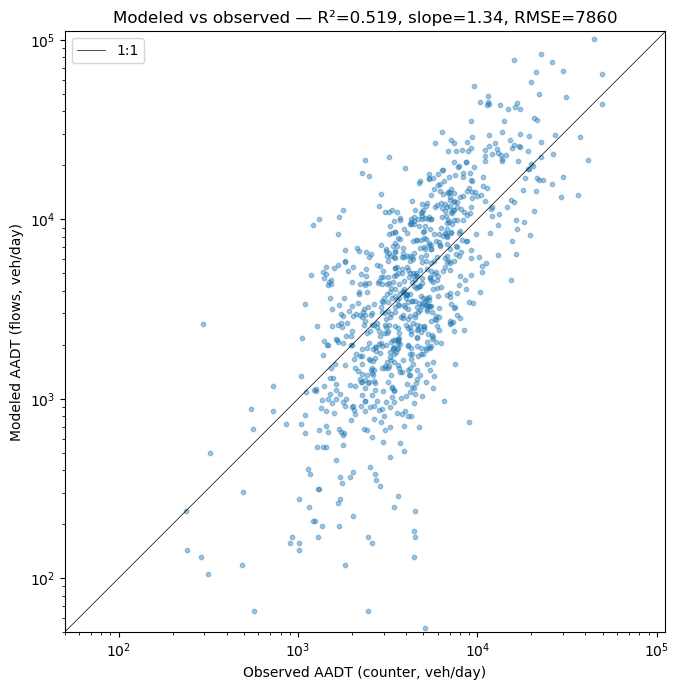

In [7]:
ev = calibration.evaluate_against_counters(flows, counters)
print(f"Fit at counters: R²={ev['r2']:.3f}, slope={ev['slope']:.3f}, "
      f"RMSE={ev['rmse']:.0f}, n={ev['n_matched']:,}")

m = ev['merged']
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(m['observed'], m['modeled'], s=10, alpha=0.4, color='tab:blue')
lim = float(max(m['observed'].max(), m['modeled'].max())) * 1.1
ax.plot([1, lim], [1, lim], color='black', linewidth=0.5, label='1:1')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(50, lim); ax.set_ylim(50, lim)
ax.set_xlabel('Observed AADT (counter, veh/day)')
ax.set_ylabel('Modeled AADT (flows, veh/day)')
ax.set_title(f'Modeled vs observed — R²={ev["r2"]:.3f}, '
             f'slope={ev["slope"]:.2f}, RMSE={ev["rmse"]:.0f}')
ax.set_aspect('equal'); ax.legend()
plt.tight_layout(); plt.show()

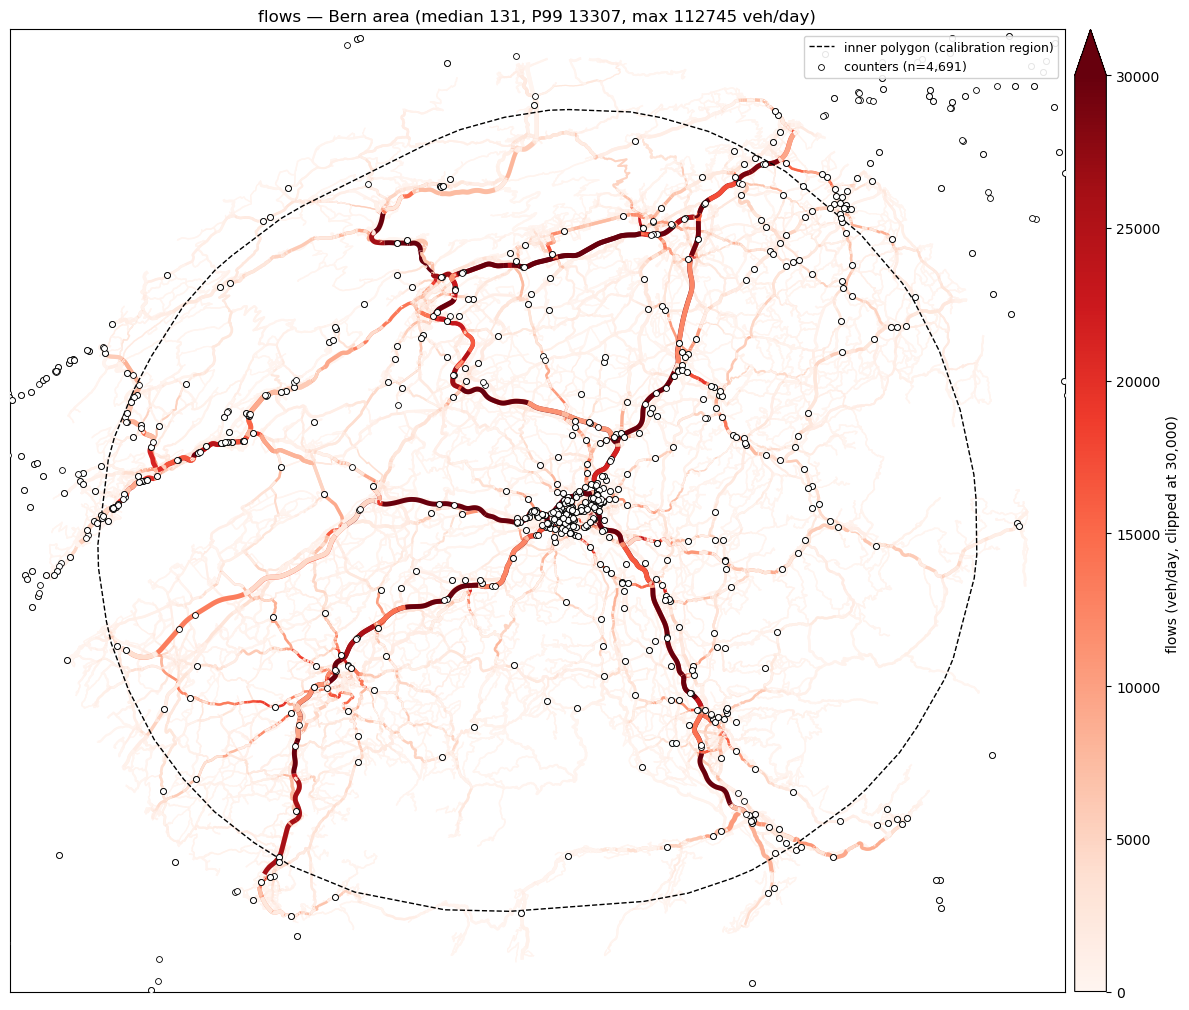

In [8]:
import _figures as figures   # noqa: E402  — project-local plot helpers

stress_arr = np.array([float(d.get('flow_estimate', 0.0))
                       for _, _, d in car_graph.edges(data=True)])

# Crop to the inner (calibration) polygon + a small pad so per-edge
# values stay legible.
_minx, _miny, _maxx, _maxy = inner_polygon.bounds
_pad_x, _pad_y = 0.10 * (_maxx - _minx), 0.10 * (_maxy - _miny)
xlim = (_minx - _pad_x, _maxx + _pad_x)
ylim = (_miny - _pad_y, _maxy + _pad_y)

FLOW_VMAX = 30_000   # AADT cap for the colour scale

fig, ax = plt.subplots(figsize=(12, 11))
figures.plot_network_map(
    ax, car_graph, flows,
    cbar_label=f'flows (veh/day, clipped at {FLOW_VMAX:,})',
    title=(f'flows — {LOCATION_LABEL} area '
           f'(median {np.median(stress_arr):.0f}, '
           f'P99 {np.quantile(stress_arr, 0.99):.0f}, '
           f'max {stress_arr.max():.0f} veh/day)'),
    xlim=xlim, ylim=ylim,
    vmax=FLOW_VMAX,
)
ax.plot(*inner_polygon.exterior.xy,
        color='black', linewidth=1.0, linestyle='--',
        label='inner polygon (calibration region)', zorder=5)
ax.scatter(counters_all.geometry.x, counters_all.geometry.y,
           s=18, facecolor='white', edgecolor='black', linewidth=0.6,
           label=f'counters (n={len(counters_all):,})', zorder=6)
_legend = ax.legend(loc='upper right', framealpha=0.9, fontsize=9)
_legend.set_zorder(20)   # above the counter dots
plt.tight_layout(); plt.show()

## What this notebook does NOT do

Beyond the no-stochastic-routing / no-capacity simplifications
flagged in the header:

- **No automated calibration against counters.** The three knobs
  (`LOGNORM_SHAPE`, `LOGNORM_SCALE`, `TRIPS_PER_PERSON_PER_DAY`)
  come from priors. Production coordinate-descents these (with a
  slope-vs-RMSE trade-off and an inner-vs-outer counter filter)
  once the sampling bias is fixed.
- **Output isn't consumed by `accessibility.ipynb`.** Each showcase
  notebook stands alone. Production *does* feed `flow_estimate` into
  edge-weight calibration as a `(V/C)²` BPR-style multiplicative
  feature — that's the link from this notebook's output to typical
  edge speeds.
- **No capacity-normalised stress map.** Dividing flows by
  `lanes × per-lane capacity` and raising to `β` (≈ 2 or 4, BPR
  convention) highlights bottlenecks regardless of road class, but
  is a deep dive. See `aperta-lab/projects/lumos/`.